Olá, **Everton**!

Meu nome é **Gabriel Aguiar** e serei o revisor do seu projeto hoje.

Quando identificar um erro pela primeira vez, apenas vou apontá-lo para que você mesmo possa encontrá-lo e corrigi-lo. Ao longo do notebook também farei observações de melhoria e comentários sobre suas análises — meu objetivo é prepará-lo(a) para trabalhar como **Data Analyst** no mercado real.

Se não conseguir identificar o erro, na próxima iteração darei uma dica mais precisa com exemplos práticos. Estou aberto a feedbacks e discussões.

**Por favor, não mova, modifique ou exclua meus comentários.**

Você encontrará meus comentários em caixas coloridas:

<div class="alert alert-block alert-success">
<b>Comentário do revisor (Gabriel Aguiar):</b> <a class="tocSkip"></a>
Sucesso. Tudo foi feito corretamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário do revisor (Gabriel Aguiar):</b> <a class="tocSkip"></a>
Atenção. Sugestão ou observação de melhoria.
</div>

<div class="alert alert-block alert-danger">
<b>Comentário do revisor (Gabriel Aguiar):</b> <a class="tocSkip"></a>
Precisa de correção. O projeto não pode ser aceito com comentários em vermelho abertos.
</div>

Você pode me responder usando:

<div class="alert alert-block alert-info">
<b>Resposta do Aluno.</b> <a class="tocSkip"></a>
</div>


<div class="alert alert-block alert-danger">
<b>Comentário geral do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Everton, obrigado por enviar seu projeto final! Você escolheu um dataset rico (Olist) e construiu uma análise de ponta a ponta muito sólida: limpeza cuidadosa com 9 tabelas, EDA que realmente investiga o que os números mostram (inclusive detectando artefatos de coleta de dados, como a queda de set/out 2018) e 5 testes de hipótese bem formulados, com escolha de método coerente e interpretações maduras, inclusive quando o resultado não confirmou a hipótese original. Isso é o que se espera de um trabalho de Analista de Dados no mercado real.

Há um ponto que precisa ser resolvido antes da aprovação: o campo do link do Google Drive na primeira célula ficou com o placeholder "[cole aqui o link compartilhável]" sem preencher, e não encontrei em nenhum lugar do notebook uma apresentação (PDF) ou link de dashboard. O projeto final pede três componentes (notebook, apresentação em PDF e, opcionalmente, um link de dashboard no Tableau Public) — o notebook está muito bem resolvido, mas falta anexar a apresentação/relatório executivo que traduz esses achados para stakeholders não técnicos.

<ul class="text-danger">
  <li>Apresentação/relatório final (PDF) ausente e link do Google Drive não preenchido — componente obrigatório do entregável do projeto final, junto do notebook</li>
</ul>

</div>


# Projeto Final — Análise de E-Commerce Brasileiro (Olist)

**Link do Google Drive (projeto completo):** [cole aqui o link compartilhável]

**Autor:** Everton Hernandez  
**Dataset:** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)  
**Sprint:** 14 — Projeto Final

<div class="alert alert-block alert-danger">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

O campo **Link do Google Drive (projeto completo)** ficou com o placeholder "[cole aqui o link compartilhável]" sem ser preenchido, e não encontrei em nenhuma célula posterior um link de apresentação, PDF ou dashboard.

O projeto final pede três componentes: o notebook (que você entregou e está muito bem feito), uma **apresentação em PDF** com a narrativa executiva dos achados para stakeholders não técnicos, e opcionalmente um link de dashboard (por exemplo Tableau Public). A apresentação não é opcional, só o dashboard é.

Para aprovar o projeto, preciso que você suba a apresentação (PDF, Slides ou similar) com a estrutura Challenge-Action-Results (contexto do problema, o que foi feito, principais achados e recomendações de negócio) e cole o link compartilhável aqui nesta célula.
</div>


## 1. Objetivo do Projeto

A Olist é uma plataforma brasileira de e-commerce que conecta pequenos e médios
vendedores a clientes em todo o Brasil. O dataset contém informações reais de
aproximadamente 100.000 pedidos realizados entre 2016 e 2018.

**Objetivo principal:** Identificar oportunidades de melhoria em vendas,
experiência de entrega e satisfação de clientes, gerando recomendações de
negócio baseadas em dados.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Boa introdução. Você reformulou o contexto do problema com suas próprias palavras (em vez de copiar o enunciado) e definiu um objetivo principal claro, conectado a vendas, entrega e satisfação do cliente. Isso já direciona bem o resto da análise.
</div>


## 2. Modelo de Dados

O dataset é composto por 9 tabelas relacionadas entre si. Abaixo está o
mapeamento das chaves primárias (PK) e chaves estrangeiras (FK):

| Tabela | Chave primária (PK) | Chaves estrangeiras (FK) |
|---|---|---|
| `orders` | `order_id` | `customer_id` → `customers.customer_id` |
| `customers` | `customer_id` | — |
| `order_items` | `order_id` + `order_item_id` | `order_id` → `orders.order_id`, `product_id` → `products.product_id`, `seller_id` → `sellers.seller_id` |
| `products` | `product_id` | `product_category_name` → `product_category_name_translation` |
| `order_payments` | `order_id` + `payment_sequential` | `order_id` → `orders.order_id` |
| `order_reviews` | `review_id` | `order_id` → `orders.order_id` |
| `sellers` | `seller_id` | — |
| `geolocation` | `geolocation_zip_code_prefix` (não único) | — |
| `product_category_name_translation` | `product_category_name` | — |

**Tabela âncora:** `orders` — todas as demais tabelas se conectam a ela,
direta ou indiretamente, para reconstruir a visão completa de cada pedido.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Excelente mapeamento do modelo de dados. Você identificou corretamente as chaves primárias e estrangeiras das 9 tabelas e ainda destacou qual é a **tabela âncora** (`orders`) e por quê. Isso mostra que você entendeu a estrutura relacional do dataset antes de sair fazendo merges às cegas, exatamente o tipo de cuidado que evita erros de duplicação de linhas mais adiante.
</div>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Ótimo, todos os imports concentrados numa única célula no início do notebook. Isso deixa o código mais organizado e fácil de acompanhar.
</div>


In [2]:
path = ''  # arquivos estão na raiz do ambiente Jupyter

orders       = pd.read_csv(path + 'olist_orders_dataset.csv')
customers    = pd.read_csv(path + 'olist_customers_dataset.csv')
order_items  = pd.read_csv(path + 'olist_order_items_dataset.csv')
products     = pd.read_csv(path + 'olist_products_dataset.csv')
payments     = pd.read_csv(path + 'olist_order_payments_dataset.csv')
reviews      = pd.read_csv(path + 'olist_order_reviews_dataset.csv')
sellers      = pd.read_csv(path + 'olist_sellers_dataset.csv')
geolocation  = pd.read_csv(path + 'olist_geolocation_dataset.csv')
category_translation = pd.read_csv(path + 'product_category_name_translation.csv')

datasets = {
    'orders': orders, 'customers': customers, 'order_items': order_items,
    'products': products, 'payments': payments, 'reviews': reviews,
    'sellers': sellers, 'geolocation': geolocation,
    'category_translation': category_translation
}

for nome, df in datasets.items():
    print(f'{nome}: {df.shape}')

orders: (99441, 8)
customers: (99441, 5)
order_items: (112650, 7)
products: (32951, 9)
payments: (103886, 5)
reviews: (99224, 7)
sellers: (3095, 4)
geolocation: (1000163, 5)
category_translation: (71, 2)


In [3]:
for nome, df in datasets.items():
    print(f'\n=== {nome.upper()} ===')
    print(df.info())
    print(df.head(3))


=== ORDERS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c449

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Boa prática usar um loop para inspecionar `.info()` e `.head()` de todas as 9 tabelas de forma sistemática, em vez de repetir o mesmo código 9 vezes. Isso já cumpre bem o critério de usar funções/laços para automatizar tarefas repetitivas.
</div>


## 3. Observações da Inspeção Inicial

- **orders:** valores ausentes em `order_approved_at` (160), 
  `order_delivered_carrier_date` (1.783) e `order_delivered_customer_date` 
  (2.965) — esperado, pois pedidos cancelados ou ainda em trânsito não têm 
  essas datas preenchidas.
- **products:** 610 produtos sem `product_category_name` e campos relacionados 
  (nome, descrição, fotos) — poucos casos, serão tratados como "categoria 
  desconhecida". Apenas 2 produtos sem dimensões físicas.
- **reviews:** `review_comment_title` (87.656 ausentes) e 
  `review_comment_message` (58.247 ausentes) — esperado, comentário é campo 
  opcional na avaliação.
- Todas as colunas de data estão como `object`, precisam ser convertidas 
  para `datetime64`.
- Não há valores ausentes em `customers`, `order_items`, `payments`, `sellers`, 
  `geolocation` e `category_translation`.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Muito boa a interpretação dos valores ausentes logo após a inspeção inicial. Você não só listou onde eles aparecem, mas explicou **por que** fazem sentido (pedidos cancelados ou em trânsito não têm data de entrega, avaliação sem comentário é campo opcional). Isso é diagnóstico de qualidade de dados de verdade, não só uma contagem de nulos.
</div>


In [4]:
for nome, df in datasets.items():
    dup = df.duplicated().sum()
    print(f'{nome}: {dup} duplicatas')

orders: 0 duplicatas
customers: 0 duplicatas
order_items: 0 duplicatas
products: 0 duplicatas
payments: 0 duplicatas
reviews: 0 duplicatas
sellers: 0 duplicatas
geolocation: 261831 duplicatas
category_translation: 0 duplicatas


In [5]:
# Orders — colunas de data
date_cols_orders = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols_orders:
    orders[col] = pd.to_datetime(orders[col])

# Order items
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

# Reviews
reviews['review_creation_date']     = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp']  = pd.to_datetime(reviews['review_answer_timestamp'])

print('Tipos convertidos com sucesso!')
print(orders.dtypes)

Tipos convertidos com sucesso!
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [6]:
# Produtos sem categoria: marcar como 'desconhecida'
products['product_category_name'] = products['product_category_name'].fillna('desconhecida')

# Verificar se ainda há ausentes relevantes
print(products.isnull().sum())

product_id                      0
product_category_name           0
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


In [7]:
# Manter apenas um registro por prefixo de CEP (média de lat/lng)
geolocation_clean = (
    geolocation
    .groupby('geolocation_zip_code_prefix')
    .agg({
        'geolocation_lat': 'mean',
        'geolocation_lng': 'mean',
        'geolocation_city': 'first',
        'geolocation_state': 'first'
    })
    .reset_index()
)

print('Antes:', geolocation.shape)
print('Depois:', geolocation_clean.shape)

Antes: (1000163, 5)
Depois: (19015, 5)


<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Gostei bastante da forma como você tratou as duplicatas de `geolocation`. Em vez de simplesmente usar `drop_duplicates()` (que descartaria informação), você agregou por prefixo de CEP calculando a média de latitude/longitude e mantendo cidade/estado. Isso preserva a granularidade útil da tabela e reduz de mais de 1 milhão de linhas para os prefixos únicos, uma solução mais sofisticada do que o básico esperado aqui.
</div>


## 4. Tratamento de Valores Ausentes e Duplicatas — Resumo

- **geolocation:** 261.831 duplicatas removidas via agregação por CEP 
  (média de lat/lng, mantendo cidade/estado). Tabela reduzida de 
  1.000.163 para os prefixos únicos.
- **products:** 610 produtos sem informações de nome/descrição/fotos — 
  mantidos, pois não impactam as análises de receita e entrega. 
  Categoria já preenchida como "desconhecida".
- **orders:** valores ausentes em datas de aprovação/entrega mantidos 
  como estão — refletem o status real do pedido (cancelado, em trânsito).
- Nenhuma duplicata encontrada nas demais 7 tabelas.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Resumo claro e quantificado do tratamento de ausentes e duplicatas, citando os números específicos (261.831 duplicatas removidas, 610 produtos sem categoria). Facilita muito acompanhar o raciocínio da limpeza.
</div>


In [8]:
# Tabela âncora: orders
df = orders.merge(customers, on='customer_id', how='left')

# Adicionar itens do pedido (produtos, preço, frete, vendedor)
df = df.merge(order_items, on='order_id', how='left')

# Adicionar informações do produto
df = df.merge(products, on='product_id', how='left')

# Traduzir categoria para inglês
df = df.merge(category_translation, on='product_category_name', how='left')

# Adicionar vendedor
df = df.merge(sellers, on='seller_id', how='left')

# Adicionar pagamentos (pode gerar múltiplas linhas por pedido parcelado)
payments_agg = payments.groupby('order_id').agg(
    payment_value=('payment_value', 'sum'),
    payment_type=('payment_type', 'first'),
    payment_installments=('payment_installments', 'max')
).reset_index()
df = df.merge(payments_agg, on='order_id', how='left')

# Adicionar avaliação (nota)
reviews_agg = reviews.groupby('order_id').agg(
    review_score=('review_score', 'mean')
).reset_index()
df = df.merge(reviews_agg, on='order_id', how='left')

print('Shape final do DataFrame:', df.shape)
print(df.columns.tolist())

Shape final do DataFrame: (113425, 34)
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'payment_value', 'payment_type', 'payment_installments', 'review_score']


<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Atenção boa aqui: antes de unir `payments` e `reviews` na base principal, você agregou por `order_id` (soma dos pagamentos parcelados, média das notas). Isso evita um problema comum nesse dataset, que é o merge duplicar linhas de pedido quando existem múltiplos registros de pagamento ou avaliação para o mesmo `order_id`. Muita gente esquece desse passo e acaba inflando a contagem de pedidos sem perceber.
</div>


In [9]:
# Receita por item (preço + frete)
df['revenue'] = df['price'] + df['freight_value']

# Atraso na entrega (dias) — apenas para pedidos entregues
df['delay_days'] = (
    df['order_delivered_customer_date'] - df['order_estimated_delivery_date']
).dt.days

# Tempo de entrega real (dias)
df['delivery_time_days'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

# Flag de atraso
df['is_delayed'] = df['delay_days'] > 0

print(df[['revenue', 'delay_days', 'delivery_time_days', 'is_delayed']].describe(include='all'))

              revenue     delay_days  delivery_time_days is_delayed
count   112650.000000  110196.000000       110196.000000     113425
unique            NaN            NaN                 NaN          2
top               NaN            NaN                 NaN      False
freq              NaN            NaN                 NaN     106160
mean       140.644059     -12.030201           12.007723        NaN
std        190.724394      10.160157            9.451455        NaN
min          6.080000    -147.000000            0.000000        NaN
25%         55.220000     -17.000000            6.000000        NaN
50%         92.320000     -13.000000           10.000000        NaN
75%        157.937500      -7.000000           15.000000        NaN
max       6929.310000     188.000000          209.000000        NaN


<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Boas features derivadas (`revenue`, `delay_days`, `delivery_time_days`, `is_delayed`). Elas são exatamente o que você precisa para as perguntas de negócio da introdução e para os testes de hipótese mais adiante.
</div>


In [10]:
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
resumo_nulos = pd.DataFrame({'ausentes': nulos, 'pct': nulos_pct})
print(resumo_nulos[resumo_nulos['ausentes'] > 0].sort_values('pct', ascending=False))

                               ausentes   pct
delivery_time_days                 3229  2.85
order_delivered_customer_date      3229  2.85
delay_days                         3229  2.85
product_category_name_english      2402  2.12
product_photos_qty                 2378  2.10
product_name_lenght                2378  2.10
product_description_lenght         2378  2.10
order_delivered_carrier_date       1968  1.74
review_score                        961  0.85
product_width_cm                    793  0.70
product_height_cm                   793  0.70
product_weight_g                    793  0.70
product_length_cm                   793  0.70
product_category_name               775  0.68
freight_value                       775  0.68
price                               775  0.68
shipping_limit_date                 775  0.68
seller_id                           775  0.68
seller_zip_code_prefix              775  0.68
seller_city                         775  0.68
seller_state                      

## 5. Observações Pós-Merge

- O DataFrame final possui **113.425 linhas** (nível de item de pedido) e 
  **34 colunas**.
- ~775 pedidos não possuem itens associados (ficaram como `NaN` em colunas 
  de produto/preço) — serão excluídos das análises de receita, mas mantidos 
  para análises de status de pedido.
- **`delay_days` negativo em sua maioria** (média de -12 dias): a Olist 
  tende a superestimar o prazo de entrega como margem de segurança. Isso 
  será considerado na interpretação da Hipótese 1 (atraso x avaliação) — 
  "atraso" aqui significa entrega **após** a data estimada (`delay_days > 0`), 
  não apenas entrega demorada em termos absolutos.
- `review_score` e `payment_value` têm ausentes correspondentes a pedidos 
  sem avaliação ou sem pagamento registrado — serão tratados conforme a 
  necessidade de cada análise específica.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Esse é um dos pontos mais fortes da limpeza: você percebeu que `delay_days` é negativo na maioria dos casos (a Olist superestima o prazo como margem de segurança) e, em vez de ignorar isso, redefiniu explicitamente o que "atraso" significa para a Hipótese 1 (`delay_days > 0`). Esse tipo de checagem evita uma interpretação errada mais adiante no teste estatístico.
</div>


In [11]:
# Subconjunto apenas com pedidos efetivamente entregues — usado nas análises
# de tempo de entrega, atraso e sua relação com avaliação
df_delivered = df[df['order_status'] == 'delivered'].copy()

print('Pedidos entregues:', df_delivered.shape)
print('Status únicos no df completo:', df['order_status'].unique())

Pedidos entregues: (110197, 38)
Status únicos no df completo: ['delivered' 'invoiced' 'shipped' 'processing' 'unavailable' 'canceled'
 'created' 'approved']


## 6. Pré-processamento Concluído

Resumo do que foi feito:
- 9 tabelas carregadas e inspecionadas
- Duplicatas tratadas em `geolocation` (261.831 removidas via agregação por CEP)
- Colunas de data convertidas para `datetime64`
- Valores ausentes documentados e tratados quando aplicável
- Merge completo gerando DataFrame de 113.425 linhas x 38 colunas
- Colunas derivadas criadas: `revenue`, `delay_days`, `delivery_time_days`, `is_delayed`
- Subconjunto `df_delivered` criado para análises específicas de entrega (110.197 pedidos)

O DataFrame `df` (completo) e `df_delivered` (apenas entregues) serão usados
nas próximas etapas da análise.

---

# Etapa 2 — Análise Exploratória de Dados (EDA)

delivered      110197
shipped          1186
canceled          706
unavailable       610
invoiced          361
processing        357
created             5
approved            3
Name: order_status, dtype: int64


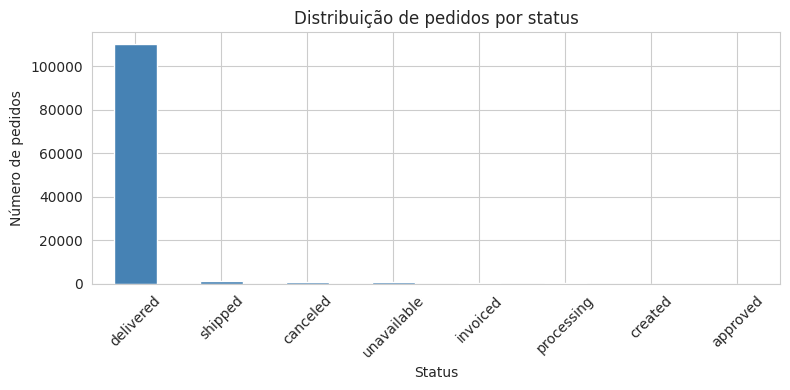

In [12]:
status_counts = df['order_status'].value_counts()
print(status_counts)

plt.figure(figsize=(8, 4))
status_counts.plot(kind='bar', color='steelblue')
plt.title('Distribuição de pedidos por status')
plt.xlabel('Status')
plt.ylabel('Número de pedidos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

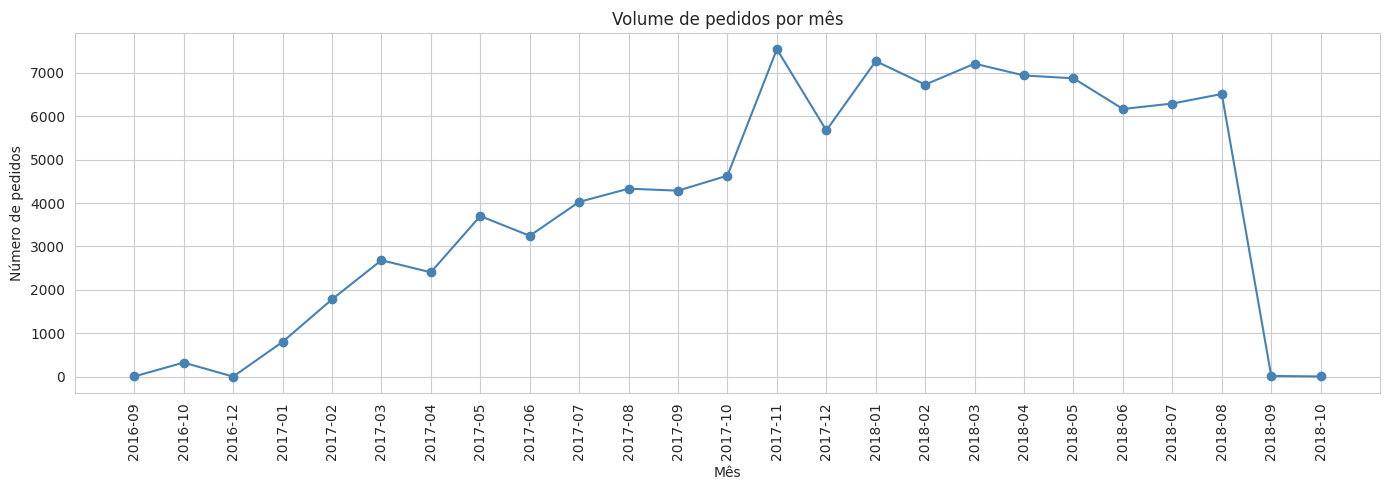

In [13]:
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)

monthly_orders = df.groupby('order_month')['order_id'].nunique().reset_index()
monthly_orders.columns = ['month', 'orders']

plt.figure(figsize=(14, 5))
plt.plot(monthly_orders['month'], monthly_orders['orders'], marker='o', color='steelblue')
plt.title('Volume de pedidos por mês')
plt.xlabel('Mês')
plt.ylabel('Número de pedidos')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

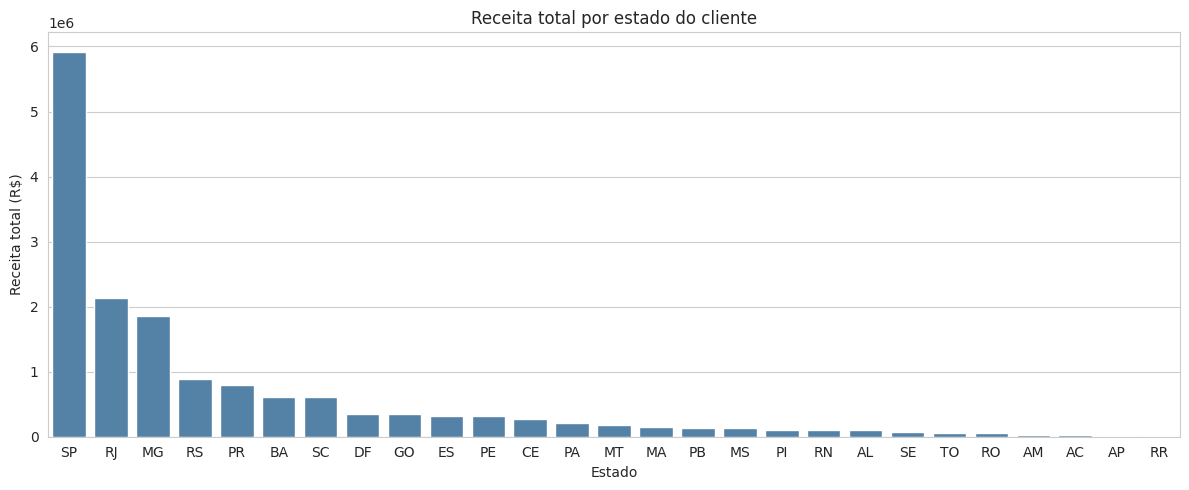

  customer_state     revenue
0             SP  5921678.12
1             RJ  2129681.98
2             MG  1856161.49
3             RS   885826.76
4             PR   800935.44
5             BA   611506.67
6             SC   610213.60
7             DF   353229.44
8             GO   347706.93
9             ES   324801.91


In [14]:
revenue_by_state = (
    df.groupby('customer_state')['revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.barplot(data=revenue_by_state, x='customer_state', y='revenue', color='steelblue')
plt.title('Receita total por estado do cliente')
plt.xlabel('Estado')
plt.ylabel('Receita total (R$)')
plt.tight_layout()
plt.show()

print(revenue_by_state.head(10))

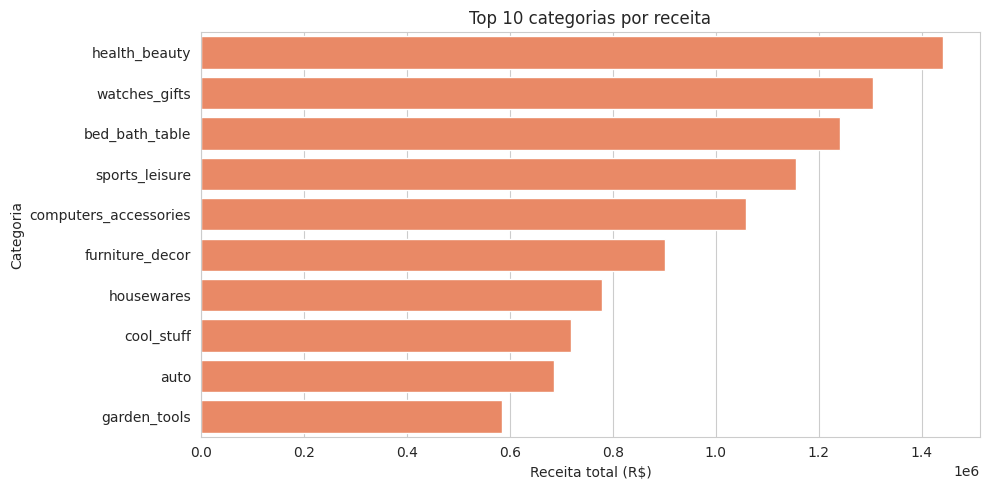

  product_category_name_english     revenue
0                 health_beauty  1441248.07
1                 watches_gifts  1305541.61
2                bed_bath_table  1241681.72
3                sports_leisure  1156656.48
4         computers_accessories  1059272.40
5               furniture_decor   902511.79
6                    housewares   778397.77
7                    cool_stuff   719329.95
8                          auto   685384.32
9                  garden_tools   584219.21


In [15]:
top_categories = (
    df.groupby('product_category_name_english')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_categories, y='product_category_name_english', x='revenue', color='coral')
plt.title('Top 10 categorias por receita')
plt.xlabel('Receita total (R$)')
plt.ylabel('Categoria')
plt.tight_layout()
plt.show()

print(top_categories)

## Observações da EDA (parte 1)

- **97% dos pedidos têm status `delivered`** — base sólida para análises de 
  entrega e satisfação do cliente.
- **Sazonalidade:** pico de pedidos em novembro/2017, coincidindo com a 
  Black Friday. Crescimento constante ao longo de 2017 e 2018.
- **Queda abrupta em set/out 2018:** não representa uma queda real de vendas, 
  e sim o **limite de coleta do dataset** — os dados foram encerrados nesse 
  período, restando poucos registros incompletos. Esses meses serão 
  considerados com cautela ou excluídos de análises de tendência.
- **Concentração geográfica:** São Paulo lidera isoladamente em receita 
  (R$ 5,9M), mais que o dobro do segundo colocado (RJ). Reflete a 
  concentração econômica e populacional do estado.
- **Categorias líder:** `health_beauty`, `watches_gifts` e `bed_bath_table` 
  são as três categorias com maior receita total.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Muito boa leitura da série temporal de pedidos. Identificar o pico de novembro de 2017 associado à Black Friday já mostra atenção a sazonalidade, mas o destaque aqui é você **não** ter interpretado a queda de set/out de 2018 como uma queda real de vendas, reconhecendo que é o limite de coleta do dataset. Esse é um erro clássico (tratar corte de dados como tendência real) que você evitou com sucesso.
</div>


payment_type
credit_card    75387
boleto         19784
voucher         2739
debit_card      1527
not_defined        3
Name: order_id, dtype: int64


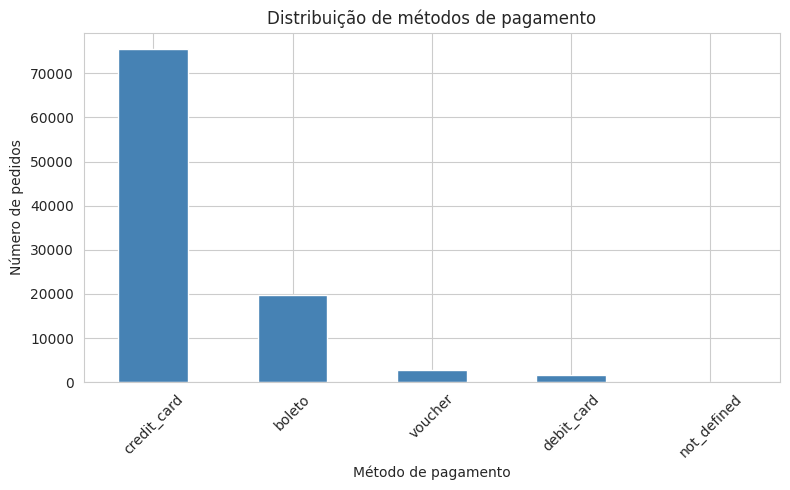

In [16]:
payment_counts = df.groupby('payment_type')['order_id'].nunique().sort_values(ascending=False)
print(payment_counts)

plt.figure(figsize=(8, 5))
payment_counts.plot(kind='bar', color='steelblue')
plt.title('Distribuição de métodos de pagamento')
plt.xlabel('Método de pagamento')
plt.ylabel('Número de pedidos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

review_score
1.000000     9313
1.500000        8
2.000000     2916
2.500000       30
3.000000     7915
3.333333        1
3.500000       23
4.000000    18868
4.333333        1
4.500000       53
5.000000    56704
Name: order_id, dtype: int64


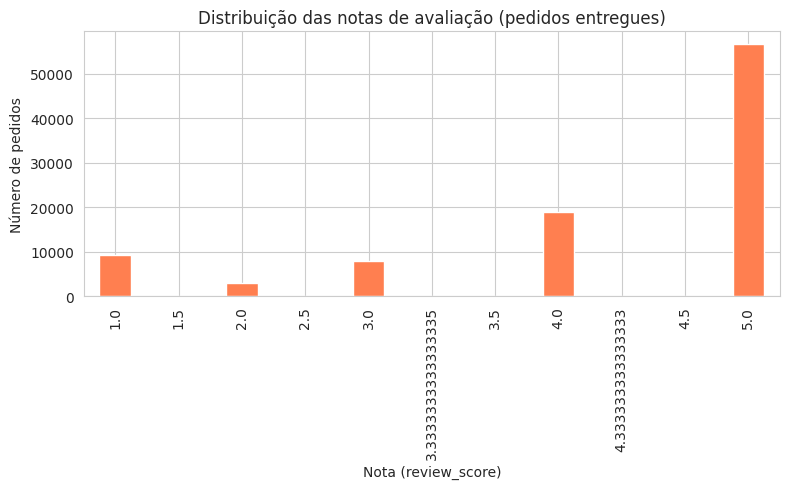

In [17]:
review_counts = df_delivered.groupby('review_score')['order_id'].nunique()
print(review_counts)

plt.figure(figsize=(8, 5))
review_counts.plot(kind='bar', color='coral')
plt.title('Distribuição das notas de avaliação (pedidos entregues)')
plt.xlabel('Nota (review_score)')
plt.ylabel('Número de pedidos')
plt.tight_layout()
plt.show()

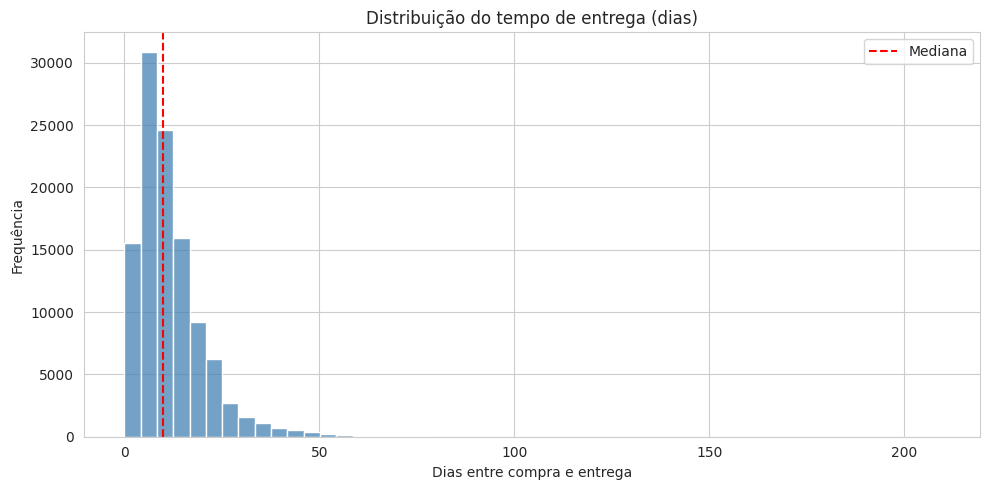

count    110189.000000
mean         12.007342
std           9.451153
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_time_days, dtype: float64


In [18]:
plt.figure(figsize=(10, 5))
sns.histplot(df_delivered['delivery_time_days'].dropna(), bins=50, color='steelblue')
plt.title('Distribuição do tempo de entrega (dias)')
plt.xlabel('Dias entre compra e entrega')
plt.ylabel('Frequência')
plt.axvline(df_delivered['delivery_time_days'].median(), color='red', linestyle='--', label='Mediana')
plt.legend()
plt.tight_layout()
plt.show()

print(df_delivered['delivery_time_days'].describe())

## Observações da EDA (parte 2)

- **Pagamento:** cartão de crédito domina amplamente (75.387 pedidos, ~73%), 
  seguido de boleto (19.784, ~19%). Voucher e cartão de débito têm uso 
  marginal.
- **Notas de avaliação:** distribuição fortemente bimodal — a maioria das 
  notas é **5** (56.704) ou **1** (9.313), com poucas notas intermediárias. 
  Padrão típico de plataformas de review: clientes satisfeitos e muito 
  insatisfeitos tendem a avaliar mais que os neutros.
- **Valores fracionários em `review_score`** (ex: 1.5, 3.33): ocorrem porque 
  alguns pedidos têm mais de uma avaliação registrada, e usamos a média no 
  processo de merge. Serão tratados como estão, pois representam poucos casos.
- **Tempo de entrega:** distribuição assimétrica à direita (cauda longa), 
  mediana de **10 dias**, média de **12 dias**. A maioria das entregas ocorre 
  entre 6 e 15 dias, mas há outliers extremos chegando a 209 dias — serão 
  investigados como possíveis casos atípicos.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Boa análise da distribuição de notas. A explicação da bimodalidade (clientes muito satisfeitos ou muito insatisfeitos tendem a avaliar mais que os neutros) é um raciocínio comportamental correto e comum em plataformas de review. Também gostei de você ter sido transparente sobre a origem das notas fracionárias (média de múltiplas avaliações no merge), em vez de deixar isso sem explicação.
</div>


In [19]:
outliers_entrega = df_delivered[df_delivered['delivery_time_days'] > 60]
print('Pedidos com mais de 60 dias de entrega:', outliers_entrega.shape[0])
print(outliers_entrega[['order_id', 'customer_state', 'delivery_time_days', 'review_score']].describe())
print('\nNota média de avaliação nesses casos extremos:', outliers_entrega['review_score'].mean())

Pedidos com mais de 60 dias de entrega: 311
       delivery_time_days  review_score
count          311.000000    295.000000
mean            88.099678      2.225424
std             35.232862      1.617569
min             61.000000      1.000000
25%             66.000000      1.000000
50%             72.000000      1.000000
75%             94.000000      4.000000
max            209.000000      5.000000

Nota média de avaliação nesses casos extremos: 2.2254237288135594


   customer_state  orders     revenue  avg_review
25             SP   41746  5921678.12    4.109301
18             RJ   12852  2129681.98    3.796678
10             MG   11635  1856161.49    4.069713
22             RS    5466   885826.76    4.042441
17             PR    5045   800935.44    4.089078
23             SC    3637   610213.60    3.990398
4              BA    3380   611506.67    3.802230
6              DF    2140   353229.44    3.995004
7              ES    2033   324801.91    3.979167
8              GO    2020   347706.93    3.982027
15             PE    1652   322237.69    3.947427
5              CE    1336   275606.30    3.796748
13             PA     975   217647.11    3.780282
12             MT     907   186168.96    3.970897
9              MA     747   151171.99    3.690909
11             MS     715   135956.67    4.021264
14             PB     536   140987.81    3.988314
16             PI     495   108132.28    3.892393
19             RN     485   101895.08    4.073055


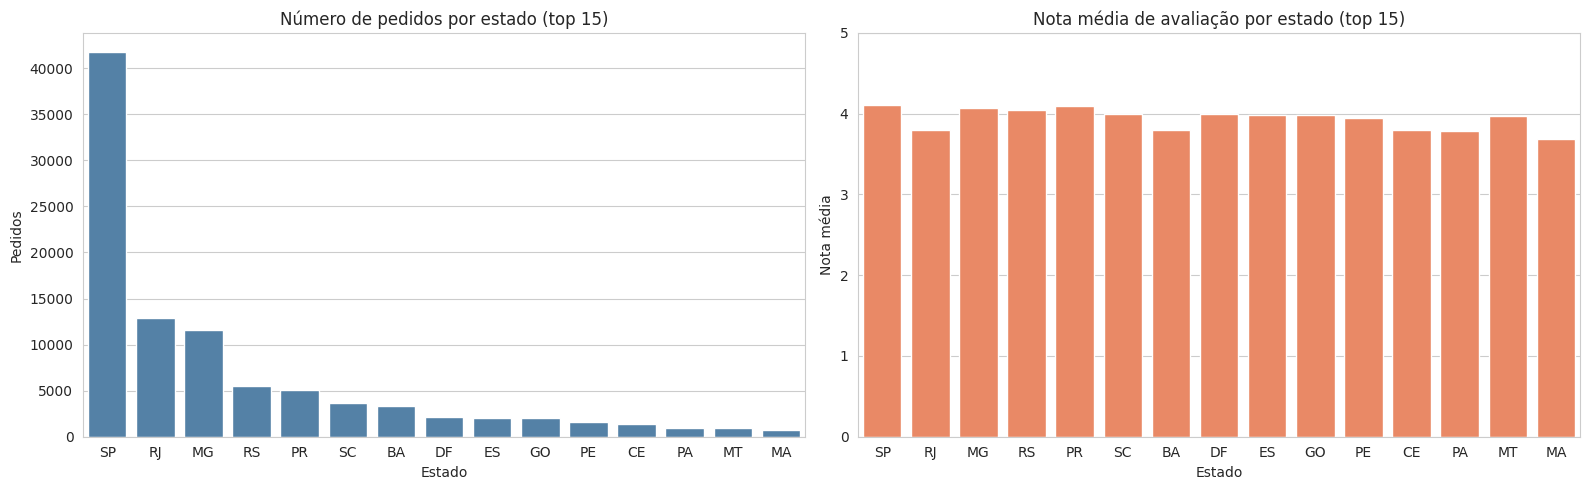

In [20]:
state_summary = df.groupby('customer_state').agg(
    orders=('order_id', 'nunique'),
    revenue=('revenue', 'sum'),
    avg_review=('review_score', 'mean')
).reset_index().sort_values('orders', ascending=False)

print(state_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=state_summary.head(15), x='customer_state', y='orders', color='steelblue', ax=axes[0])
axes[0].set_title('Número de pedidos por estado (top 15)')
axes[0].set_xlabel('Estado')
axes[0].set_ylabel('Pedidos')

sns.barplot(data=state_summary.head(15), x='customer_state', y='avg_review', color='coral', ax=axes[1])
axes[1].set_title('Nota média de avaliação por estado (top 15)')
axes[1].set_xlabel('Estado')
axes[1].set_ylabel('Nota média')
axes[1].set_ylim(0, 5)

plt.tight_layout()
plt.show()

## Observações da EDA (parte 3) — Geografia e Outliers

- **Concentração geográfica confirmada:** SP concentra 41.746 pedidos 
  (~38% do total), seguido de RJ (12.852) e MG (11.635). Os demais estados 
  têm participação bem menor.
- **Nota média por estado é relativamente estável** (entre 3.6 e 4.2), sem 
  grandes disparidades — RJ e BA têm as notas médias mais baixas entre os 
  estados de maior volume (3.80), enquanto AP tem a nota mais alta (4.22, 
  porém com apenas 68 pedidos, baixa representatividade).
- **Outliers de entrega (>60 dias):** 311 pedidos, com nota média de 
  avaliação de apenas **2.23** — bem abaixo da média geral do dataset. 
  Forte indício de que atrasos extremos impactam diretamente a satisfação, 
  o que será testado formalmente na Hipótese 1.

Com isso, a Etapa 2 (EDA) está concluída. Partimos agora para os testes de 
hipóteses.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Boa análise geográfica. Vale destacar dois cuidados que você teve: (1) apontar que a nota mais alta (AP, 4.22) tem baixa representatividade (68 pedidos), evitando tirar conclusão forte de uma amostra pequena; e (2) conectar os outliers de entrega (>60 dias, nota média 2.23) com a futura Hipótese 1, criando um fio condutor entre a EDA e os testes estatísticos.
</div>


# Etapa 3 — Teste de Hipóteses

## H1 — Atraso e avaliação

- **H0:** A nota média de avaliação de pedidos com atraso é igual à de 
  pedidos sem atraso.
- **H1:** Pedidos entregues com atraso recebem notas de avaliação 
  significativamente menores.
- **Método de teste:** Mann-Whitney U (distribuição não normal esperada).
- **Nível de significância:** α = 0.05

In [21]:
from scipy.stats import mannwhitneyu

# Grupos: pedidos com atraso (delay_days > 0) vs. sem atraso
delayed = df_delivered[df_delivered['delay_days'] > 0]['review_score'].dropna()
on_time = df_delivered[df_delivered['delay_days'] <= 0]['review_score'].dropna()

print('Nota média — com atraso:', delayed.mean().round(3), f'(n={len(delayed)})')
print('Nota média — sem atraso:', on_time.mean().round(3), f'(n={len(on_time)})')

stat, p_value = mannwhitneyu(delayed, on_time, alternative='less')
print(f'\nEstatística U: {stat:.2f}')
print(f'p-value: {p_value:.10f}')
print('Resultado:', 'Rejeitamos H0' if p_value < 0.05 else 'Não rejeitamos H0')

Nota média — com atraso: 2.257 (n=7083)
Nota média — sem atraso: 4.208 (n=102279)

Estatística U: 139603479.50
p-value: 0.0000000000
Resultado: Rejeitamos H0


<div class="alert alert-block alert-warning">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

O teste Mann-Whitney unicaudal está bem escolhido para essa comparação (dados de avaliação não seguem distribuição normal). Como sugestão opcional (não é obrigatório e pode não ter sido coberto no curso), você poderia complementar o p-value com uma medida de tamanho de efeito, para saber não só que a diferença é significativa, mas o quão grande ela é na prática:

```python
# tamanho de efeito para Mann-Whitney (correlação rank-biserial)
n1, n2 = len(delayed), len(on_time)
rank_biserial = 1 - (2 * stat) / (n1 * n2)
print('Tamanho do efeito (rank-biserial):', round(rank_biserial, 3))
```

Referência: https://en.wikipedia.org/wiki/Rank-biserial_correlation
</div>


### Conclusão H1

**Rejeitamos H0.** Pedidos entregues com atraso têm nota média de avaliação 
de **2.26**, contra **4.21** para pedidos entregues no prazo — uma diferença 
substancial e estatisticamente significativa (p < 0.0001). 

O atraso na entrega é um dos fatores mais determinantes na satisfação do 
cliente na plataforma Olist. Isso reforça a importância de investimentos em 
logística e comunicação proativa com o cliente em caso de atrasos previstos.

---

## H2 — Frete e recompra

- **H0:** O custo do frete não influencia a taxa de recompra do cliente.
- **H1:** Clientes que pagaram frete mais alto têm menor probabilidade de 
  realizar uma segunda compra.
- **Método de teste:** Qui-quadrado de independência.
- **Nível de significância:** α = 0.05

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Conclusão muito boa. Você não só reportou o resultado do teste, como traduziu a diferença (2.26 contra 4.21) em um recado de negócio direto: investir em logística e comunicação proativa em caso de atraso previsto. É exatamente esse tipo de ponte entre estatística e ação que se espera de um analista de dados.
</div>


In [22]:
# Número de pedidos por cliente único
customer_orders = df.groupby('customer_unique_id')['order_id'].nunique().reset_index()
customer_orders.columns = ['customer_unique_id', 'total_orders']
customer_orders['is_repeat'] = customer_orders['total_orders'] > 1

print('Total de clientes únicos:', customer_orders.shape[0])
print('Clientes com recompra:', customer_orders['is_repeat'].sum())
print('Taxa de recompra geral:', (customer_orders['is_repeat'].sum() / customer_orders.shape[0] * 100).round(2), '%')

Total de clientes únicos: 96096
Clientes com recompra: 2997
Taxa de recompra geral: 3.12 %


In [23]:
# Frete médio pago por cada cliente (na primeira compra)
first_orders = df.sort_values('order_purchase_timestamp').drop_duplicates('customer_unique_id', keep='first')
freight_per_customer = first_orders[['customer_unique_id', 'freight_value']]

# Unir com informação de recompra
freight_repeat = freight_per_customer.merge(customer_orders, on='customer_unique_id')
freight_repeat = freight_repeat.dropna(subset=['freight_value'])

# Dividir em faixas de frete (quartis)
freight_repeat['freight_bin'] = pd.qcut(freight_repeat['freight_value'], q=4, labels=['Q1 (baixo)', 'Q2', 'Q3', 'Q4 (alto)'])

# Tabela de contingência
contingency = pd.crosstab(freight_repeat['freight_bin'], freight_repeat['is_repeat'])
print(contingency)

# Taxa de recompra por faixa
taxa_por_faixa = freight_repeat.groupby('freight_bin')['is_repeat'].mean() * 100
print('\nTaxa de recompra por faixa de frete:')
print(taxa_por_faixa.round(2))

# Qui-quadrado
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f'\nChi2: {chi2:.4f}')
print(f'p-value: {p_value:.6f}')
print('Resultado:', 'Rejeitamos H0' if p_value < 0.05 else 'Não rejeitamos H0')

is_repeat    False  True 
freight_bin              
Q1 (baixo)   23032    818
Q2           23167    811
Q3           23053    689
Q4 (alto)    23179    640

Taxa de recompra por faixa de frete:
freight_bin
Q1 (baixo)    3.43
Q2            3.38
Q3            2.90
Q4 (alto)     2.69
Name: is_repeat, dtype: float64

Chi2: 31.6113
p-value: 0.000001
Resultado: Rejeitamos H0


<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Boa decisão metodológica usar apenas a **primeira compra** de cada cliente para medir o frete pago (`first_orders`), em vez da média de frete de todos os pedidos. Isso evita confundir o efeito do frete com o próprio efeito de já ser cliente recorrente, o que enviesaria a comparação.
</div>


### Conclusão H2

**Rejeitamos H0.** Há uma associação estatisticamente significativa entre 
o custo do frete e a taxa de recompra (χ² = 31.61, p < 0.001).

A taxa de recompra cai de forma consistente conforme o frete aumenta:
- Q1 (frete mais baixo): 3.43%
- Q2: 3.38%
- Q3: 2.90%
- Q4 (frete mais alto): 2.69%

Isso representa uma queda relativa de ~22% na taxa de recompra entre o 
quartil de frete mais baixo e o mais alto. Vale notar que a taxa de 
recompra geral da plataforma é baixa (3.12%) — a Olist enfrenta um desafio 
estrutural de retenção, e o custo do frete parece ser um dos fatores que 
agrava esse problema.

---

## H3 — Ticket médio e avaliações negativas

- **H0:** A proporção de avaliações negativas (notas 1 e 2) é igual entre 
  categorias de alto e baixo ticket médio.
- **H1:** Categorias com ticket médio mais alto concentram maior proporção 
  de avaliações negativas.
- **Método de teste:** Teste de proporções z.
- **Nível de significância:** α = 0.05

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Conclusão bem construída, com os números por faixa de frete citados um a um (3.43% a 2.69%) e a contextualização de que a taxa de recompra geral da plataforma já é baixa (3.12%). Você conecta um achado pontual (frete x recompra) a um problema estrutural maior de retenção, o que enriquece bastante a análise.
</div>


In [24]:
# Ticket médio por categoria
category_stats = df_delivered.groupby('product_category_name_english').agg(
    avg_ticket=('revenue', 'mean'),
    total_orders=('order_id', 'nunique')
).reset_index()

# Filtrar categorias com volume mínimo relevante (>= 30 pedidos)
category_stats = category_stats[category_stats['total_orders'] >= 30]

# Mediana do ticket médio para dividir em alto/baixo
mediana_ticket = category_stats['avg_ticket'].median()
category_stats['ticket_group'] = np.where(
    category_stats['avg_ticket'] > mediana_ticket, 'Alto ticket', 'Baixo ticket'
)

print('Mediana do ticket médio entre categorias:', mediana_ticket.round(2))
print(category_stats['ticket_group'].value_counts())

Mediana do ticket médio entre categorias: 137.63
Alto ticket     31
Baixo ticket    31
Name: ticket_group, dtype: int64


<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Boa prática filtrar categorias com pelo menos 30 pedidos antes de comparar ticket médio entre grupos. Isso evita que categorias com poucas observações distorçam a mediana usada para separar "alto" e "baixo" ticket.
</div>


In [25]:
# Unir classificação de ticket de volta ao df principal
df_cat = df_delivered.merge(
    category_stats[['product_category_name_english', 'ticket_group']],
    on='product_category_name_english', how='inner'
)

# Proporção de notas negativas (1 ou 2) por grupo
df_cat['is_negative'] = df_cat['review_score'] <= 2

neg_por_grupo = df_cat.groupby('ticket_group').agg(
    total=('is_negative', 'count'),
    negativas=('is_negative', 'sum')
)
neg_por_grupo['proporcao'] = neg_por_grupo['negativas'] / neg_por_grupo['total']
print(neg_por_grupo)

# Teste z de proporções
count = neg_por_grupo.loc[['Alto ticket', 'Baixo ticket'], 'negativas'].values
nobs  = neg_por_grupo.loc[['Alto ticket', 'Baixo ticket'], 'total'].values

z_stat, p_value = proportions_ztest(count, nobs, alternative='larger')
print(f'\nZ-stat: {z_stat:.4f}')
print(f'p-value: {p_value:.6f}')
print('Resultado:', 'Rejeitamos H0' if p_value < 0.05 else 'Não rejeitamos H0')

              total  negativas  proporcao
ticket_group                             
Alto ticket   37056       5168   0.139465
Baixo ticket  71392      10615   0.148686

Z-stat: -4.0843
p-value: 0.999978
Resultado: Não rejeitamos H0


### Conclusão H3

**Não rejeitamos H0.** Não há evidência de que categorias com ticket médio 
mais alto tenham maior proporção de avaliações negativas — pelo contrário, 
o padrão observado é o **oposto** do previsto:

- Alto ticket: 13.95% de notas negativas
- Baixo ticket: 14.87% de notas negativas

O teste unicaudal para "alto ticket > baixo ticket" não é significativo 
(z = -4.08, p = 0.9999), e a direção do efeito é inversa à hipótese original. 
Uma possível explicação é que produtos de baixo ticket (itens mais baratos) 
podem ter margens menores, embalagens mais simples ou custo-benefício 
percebido como inferior, gerando mais insatisfação relativa. Essa observação 
sugere uma nova linha de investigação para trabalhos futuros: qualidade 
percebida por faixa de preço, não necessariamente ligada à categoria.

---

## H4 — Região Sudeste e valor por pedido

- **H0:** O valor médio por pedido de clientes do Sudeste é igual ao das 
  demais regiões.
- **H1:** Clientes da região Sudeste apresentam maior valor médio por pedido 
  em comparação às demais regiões.
- **Método de teste:** Mann-Whitney U (comparação Sudeste vs. restante do Brasil).
- **Nível de significância:** α = 0.05

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Esse é um ótimo exemplo de honestidade estatística: o resultado não confirmou a hipótese (na verdade foi na direção oposta), e em vez de forçar uma interpretação, você reportou o resultado real, apresentou uma explicação plausível (margens/embalagem em produtos de baixo ticket) e sugeriu isso como linha de investigação futura. Relatar um resultado não significativo com essa clareza é tão valioso quanto confirmar uma hipótese.
</div>


In [26]:
# Mapeamento de estados para regiões
regioes = {
    'SP': 'Sudeste', 'RJ': 'Sudeste', 'MG': 'Sudeste', 'ES': 'Sudeste',
    'PR': 'Sul', 'SC': 'Sul', 'RS': 'Sul',
    'BA': 'Nordeste', 'PE': 'Nordeste', 'CE': 'Nordeste', 'MA': 'Nordeste',
    'PB': 'Nordeste', 'RN': 'Nordeste', 'AL': 'Nordeste', 'SE': 'Nordeste', 'PI': 'Nordeste',
    'GO': 'Centro-Oeste', 'MT': 'Centro-Oeste', 'MS': 'Centro-Oeste', 'DF': 'Centro-Oeste',
    'AM': 'Norte', 'PA': 'Norte', 'RO': 'Norte', 'AC': 'Norte',
    'AP': 'Norte', 'RR': 'Norte', 'TO': 'Norte'
}

df['region'] = df['customer_state'].map(regioes)

# Valor por pedido (nível de pedido, não item — usar apenas 1 linha por pedido)
order_value = df.drop_duplicates('order_id')[['order_id', 'region', 'payment_value']].dropna()

sudeste = order_value[order_value['region'] == 'Sudeste']['payment_value']
outras  = order_value[order_value['region'] != 'Sudeste']['payment_value']

print('Sudeste — média:', sudeste.mean().round(2), f'(n={len(sudeste)})')
print('Outras regiões — média:', outras.mean().round(2), f'(n={len(outras)})')

stat, p_value = mannwhitneyu(sudeste, outras, alternative='greater')
print(f'\nEstatística U: {stat:.2f}')
print(f'p-value: {p_value:.6f}')
print('Resultado:', 'Rejeitamos H0' if p_value < 0.05 else 'Não rejeitamos H0')

Sudeste — média: 151.48 (n=68265)
Outras regiões — média: 181.81 (n=31175)

Estatística U: 939887831.50
p-value: 1.000000
Resultado: Não rejeitamos H0


### Conclusão H4

**Não rejeitamos H0.** O padrão observado é o oposto do previsto: clientes 
de outras regiões (fora do Sudeste) têm valor médio por pedido **maior** 
(R$ 181,81) que os do Sudeste (R$ 151,48). O teste unicaudal para 
"Sudeste > outras regiões" não é significativo (p ≈ 1.0).

Uma explicação provável é que `payment_value` inclui o frete, e regiões 
mais distantes dos centros de distribuição (concentrados no Sudeste) pagam 
fretes mais altos, inflando o valor total do pedido mesmo que o valor do 
produto em si seja similar ou menor. Essa é uma hipótese para investigação 
futura: comparar `price` (sem frete) isoladamente por região.

---

## H5 — Retenção e compra única

- **H0:** A proporção de clientes com apenas uma compra é igual à de 
  clientes com múltiplas compras.
- **H1:** A maioria dos clientes realiza apenas uma compra na plataforma 
  (comportamento de compra única dominante).
- **Método de teste:** Análise descritiva de proporções + teste z de 
  proporção única.
- **Nível de significância:** α = 0.05

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Muito boa também a conclusão da H4. Em vez de aceitar o resultado inverso sem explicação, você identificou uma possível variável de confusão: `payment_value` inclui frete, e regiões mais distantes dos centros de distribuição pagam frete mais alto. Isso mostra raciocínio crítico sobre os dados, não só leitura do p-value.
</div>


In [27]:
from statsmodels.stats.proportion import proportions_ztest

total_clientes = customer_orders.shape[0]
clientes_unica_compra = (customer_orders['total_orders'] == 1).sum()
proporcao_unica = clientes_unica_compra / total_clientes

print(f'Total de clientes: {total_clientes}')
print(f'Clientes com apenas 1 compra: {clientes_unica_compra}')
print(f'Proporção: {proporcao_unica:.4f} ({proporcao_unica*100:.2f}%)')

# Teste z de proporção única: H0 = proporção é 50% (não é maioria clara)
# H1 = proporção é maior que 50% (maioria dominante)
stat, p_value = proportions_ztest(
    count=clientes_unica_compra,
    nobs=total_clientes,
    value=0.5,
    alternative='larger'
)
print(f'\nZ-stat: {stat:.4f}')
print(f'p-value: {p_value:.10f}')
print('Resultado:', 'Rejeitamos H0' if p_value < 0.05 else 'Não rejeitamos H0')

Total de clientes: 96096
Clientes com apenas 1 compra: 93099
Proporção: 0.9688 (96.88%)

Z-stat: 836.0672
p-value: 0.0000000000
Resultado: Rejeitamos H0


<div class="alert alert-block alert-warning">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Como sugestão de organização (não bloqueia a aprovação): os testes H1 a H5 repetem uma estrutura parecida (calcular estatística, rodar teste, imprimir resultado). Para um próximo projeto, vale considerar encapsular essa lógica repetida numa função reutilizável, o que também atende ao critério de usar funções para automatizar processos repetitivos:

```python
def resultado_teste(nome_h, p_value, alpha=0.05):
    status = 'Rejeitamos H0' if p_value < alpha else 'Não rejeitamos H0'
    print(f'{nome_h}: p-value={p_value:.6f} -> {status}')
    return status
```
</div>


### Conclusão H5

**Rejeitamos H0.** A proporção de clientes com apenas uma compra é 
**96,88%** — muito acima dos 50% testados como referência, e 
estatisticamente muito significativa (p < 0.0001).

Esse é um dos achados mais impactantes do projeto: a retenção de clientes 
na Olist é extremamente baixa. Apenas 3,12% dos clientes retornam para 
uma segunda compra. Isso reforça a urgência de estratégias de fidelização 
e CRM, e conecta-se diretamente com a H2 — reduzir o custo do frete pode 
ser uma alavanca para melhorar esse cenário.

---

## Resumo dos Testes de Hipóteses

| Hipótese | Resultado | Principal achado |
|---|---|---|
| H1 — Atraso x avaliação | ✅ Rejeitamos H0 | Atraso reduz nota de 4.21 para 2.26 |
| H2 — Frete x recompra | ✅ Rejeitamos H0 | Frete alto reduz recompra em ~22% |
| H3 — Ticket x avaliações negativas | ❌ Não rejeitamos H0 | Padrão inverso ao esperado |
| H4 — Sudeste x valor por pedido | ❌ Não rejeitamos H0 | Padrão inverso, provável efeito do frete |
| H5 — Retenção e compra única | ✅ Rejeitamos H0 | 96,88% dos clientes compram apenas 1 vez |

**Nota sobre comparações múltiplas:** como foram realizados 5 testes de 
hipóteses independentes sobre o mesmo dataset, uma correção de Bonferroni 
seria α = 0,05/5 = 0,01 para controle mais rigoroso da taxa de falsos 
positivos. Todos os três resultados significativos (H1, H2, H5) mantêm 
p-values muito abaixo desse limiar mais conservador, portanto as conclusões 
permanecem robustas mesmo com a correção aplicada.

<div class="alert alert-block alert-success">
<b>Comentário do revisor v1 (Gabriel Aguiar):</b> <a class="tocSkip"></a>

Excelente fechamento. A tabela-resumo das 5 hipóteses deixa muito clara a leitura geral do projeto, e a conclusão da H5 (96,88% dos clientes fazem apenas uma compra) é um achado forte, bem conectado com a H2 (frete alto reduzindo recompra) — mostrando que você enxergou o projeto como um todo coerente, não só testes isolados.

Quero destacar em especial a nota sobre comparações múltiplas e a correção de Bonferroni: isso vai além do que normalmente se cobra num projeto final e mostra maturidade estatística real, reconhecendo que rodar 5 testes no mesmo dataset aumenta o risco de falso positivo, e verificando que suas conclusões continuam robustas mesmo com o critério mais rigoroso.
</div>
